# Seoul Bike Demand Regression

## Goal

This notebook predicts hourly bike rental demand in Seoul using weather, time, season, and holiday information.

The project focuses on:

- regression modelling
- time-aware train/validation/test splitting
- feature engineering from date and hour
- handling numerical and categorical variables
- comparing baseline, linear, random forest, and gradient boosting models
- evaluating with MAE, RMSE, and R²
- analysing model errors by hour, season, and weather condition
- interpreting feature importance

In [35]:
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
dataset_path = kagglehub.dataset_download("saurabhshahane/seoul-bike-sharing-demand-prediction")
dataset_path = Path(dataset_path)

print("Dataset downloaded to:", dataset_path)

csv_files = list(dataset_path.rglob("*.csv"))
csv_files

100%|██████████| 126k/126k [00:00<00:00, 206kB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\saurabhshahane\seoul-bike-sharing-demand-prediction\versions\1


[WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/saurabhshahane/seoul-bike-sharing-demand-prediction/versions/1/SeoulBikeData.csv')]

In [4]:
def read_csv_with_fallback(path):
    encodings = ["utf-8", "latin1", "cp949"]
    
    for encoding in encodings:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    
    raise UnicodeDecodeError("Could not read file with common encodings.")


df = read_csv_with_fallback(csv_files[0])

df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [8]:
def clean_column_name(name):
    name = name.strip()
    name = name.lower()
    name = name.replace(" ", "_")
    name = name.replace("(", "")
    name = name.replace(")", "")
    name = name.replace("°", "")
    name = name.replace("/", "_")
    name = name.replace("-", "_")
    name = name.replace(".", "")
    name = name.replace("%", "percent")
    return name

df.columns = [clean_column_name(col) for col in df.columns]

df.head()

,date,rented_bike_count,hour,temperaturec,humiditypercent,wind_speed_m_s,visibility_10m,dew_point_temperaturec,solar_radiation_mj_m2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [9]:
df.columns.tolist()

['date',
 'rented_bike_count',
 'hour',
 'temperaturec',
 'humiditypercent',
 'wind_speed_m_s',
 'visibility_10m',
 'dew_point_temperaturec',
 'solar_radiation_mj_m2',
 'rainfallmm',
 'snowfall_cm',
 'seasons',
 'holiday',
 'functioning_day']

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rented_bike_count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
temperaturec,8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
humiditypercent,8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
wind_speed_m_s,8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
visibility_10m,8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
dew_point_temperaturec,8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
solar_radiation_mj_m2,8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
rainfallmm,8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


In [12]:
target_col = "rented_bike_count"

df[target_col].describe()

count    8760.000000
mean      704.602055
std       644.997468
min         0.000000
25%       191.000000
50%       504.500000
75%      1065.250000
max      3556.000000
Name: rented_bike_count, dtype: float64

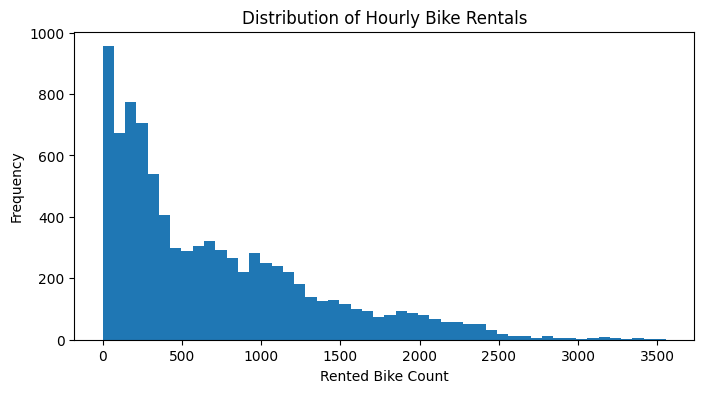

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(df[target_col], bins=50)
plt.title("Distribution of Hourly Bike Rentals")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.show()

## Target distribution note

The target variable is right-skewed. Most hourly observations have relatively low to moderate bike rental counts, while a smaller number of peak hours have very high demand.

The full dataset contains 8,760 rows. The average hourly rented bike count is about 704.60, the median is 504.50, and the maximum is 3,556. This means the model needs to handle both normal demand periods and occasional high-demand peaks.

In [14]:
df["functioning_day"].value_counts()

functioning_day
Yes    8465
No      295
Name: count, dtype: int64

In [15]:
df.groupby("functioning_day")[target_col].describe()

,count,mean,std,min,25%,50%,75%,max
functioning_day,,,,,,,,
No,295.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Yes,8465.0,729.156999,642.351166,2.0,214.0,542.0,1084.0,3556.0


In [16]:
df_model = df[df["functioning_day"] == "Yes"].copy()

df_model = df_model.drop(columns=["functioning_day"])

df_model.shape

(8465, 13)

In [17]:
df_model["date"] = pd.to_datetime(df_model["date"], dayfirst=True, errors="coerce")

df_model["date"].isna().sum()

np.int64(0)

In [18]:
df_model["month"] = df_model["date"].dt.month
df_model["day_of_week"] = df_model["date"].dt.dayofweek
df_model["is_weekend"] = df_model["day_of_week"].isin([5, 6]).astype(int)

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

df_model.head()

,date,rented_bike_count,hour,temperaturec,humiditypercent,wind_speed_m_s,visibility_10m,dew_point_temperaturec,solar_radiation_mj_m2,rainfallmm,snowfall_cm,seasons,holiday,month,day_of_week,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.000000,1.000000,-2.449294e-16,1.0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.258819,0.965926,-2.449294e-16,1.0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.500000,0.866025,-2.449294e-16,1.0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.707107,0.707107,-2.449294e-16,1.0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.866025,0.500000,-2.449294e-16,1.0


In [19]:
df_model = df_model.sort_values(["date", "hour"]).reset_index(drop=True)

df_model[["date", "hour", target_col]].head()

,date,hour,rented_bike_count
0,2017-12-01,0,254
1,2017-12-01,1,204
2,2017-12-01,2,173
3,2017-12-01,3,107
4,2017-12-01,4,78


## Feature engineering note

The date column was successfully converted into datetime format with no missing dates.

Several time-based features were created, including month, day of week, weekend indicator, cyclical hour features, and cyclical month features.

Cyclical encoding is useful here because hour and month repeat in cycles. For example, hour 23 and hour 0 are close in real time, even though their raw numerical values are far apart.

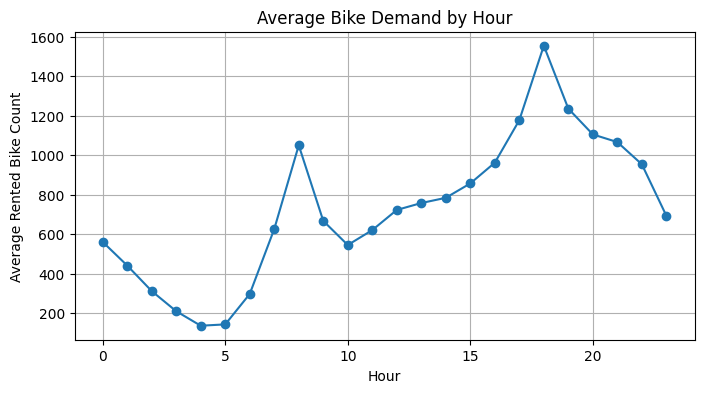

In [20]:
hourly_demand = df_model.groupby("hour")[target_col].mean()

plt.figure(figsize=(8, 4))
hourly_demand.plot(kind="line", marker="o")
plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rented Bike Count")
plt.grid(True)
plt.show()

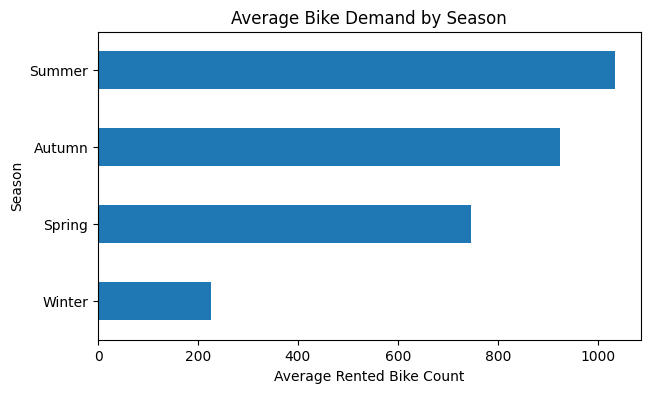

In [21]:
season_demand = df_model.groupby("seasons")[target_col].mean().sort_values()

plt.figure(figsize=(7, 4))
season_demand.plot(kind="barh")
plt.title("Average Bike Demand by Season")
plt.xlabel("Average Rented Bike Count")
plt.ylabel("Season")
plt.show()

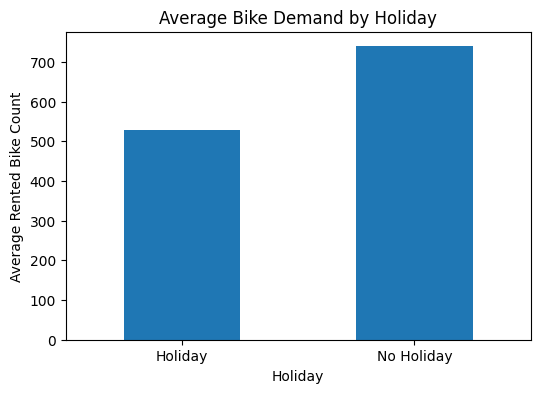

In [22]:
holiday_demand = df_model.groupby("holiday")[target_col].mean().sort_values()

plt.figure(figsize=(6, 4))
holiday_demand.plot(kind="bar")
plt.title("Average Bike Demand by Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Rented Bike Count")
plt.xticks(rotation=0)
plt.show()

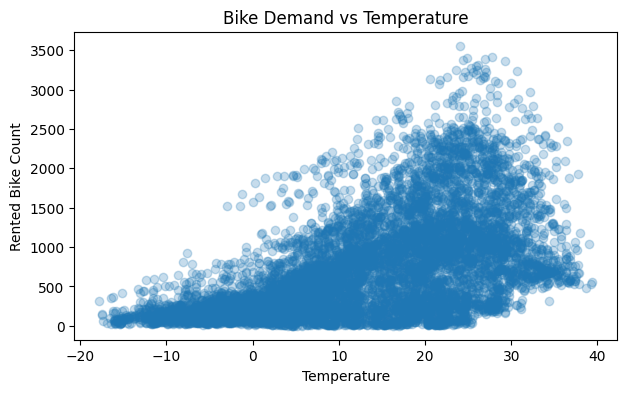

In [23]:
plt.figure(figsize=(7, 4))
plt.scatter(df_model["temperaturec"], df_model[target_col], alpha=0.25)
plt.title("Bike Demand vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Rented Bike Count")
plt.show()

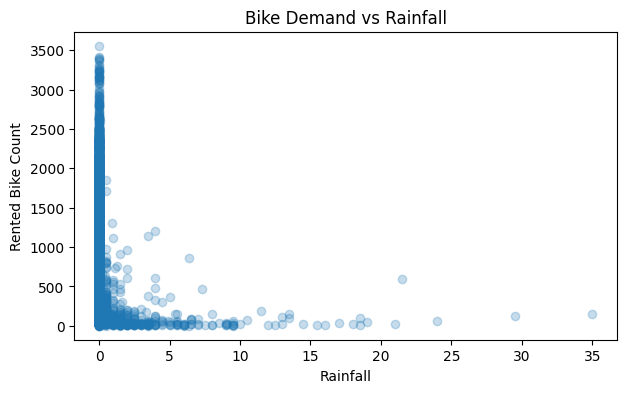

In [24]:
plt.figure(figsize=(7, 4))
plt.scatter(df_model["rainfallmm"], df_model[target_col], alpha=0.25)
plt.title("Bike Demand vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("Rented Bike Count")
plt.show()

## EDA observations

Bike demand changes strongly by hour. Demand is lowest during early morning hours and increases during the day, with clear peaks around commuting hours.

Demand is highest in summer, followed by autumn and spring. Winter has the lowest average demand.

No-holiday periods have higher average demand than holiday periods.

Temperature has a positive relationship with demand up to a point. Higher temperatures are generally associated with more bike rentals, although the relationship is not perfectly linear.

Rainfall has a negative relationship with demand. Most high-demand observations occur when rainfall is zero, while rainy periods usually have lower rental counts.

In [25]:
drop_cols = [
    target_col,
    "date"
]

X = df_model.drop(columns=drop_cols)
y = df_model[target_col]

X.head()

,hour,temperaturec,humiditypercent,wind_speed_m_s,visibility_10m,dew_point_temperaturec,solar_radiation_mj_m2,rainfallmm,snowfall_cm,seasons,holiday,month,day_of_week,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.000000,1.000000,-2.449294e-16,1.0
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.258819,0.965926,-2.449294e-16,1.0
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.500000,0.866025,-2.449294e-16,1.0
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.707107,0.707107,-2.449294e-16,1.0
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,12,4,0,0.866025,0.500000,-2.449294e-16,1.0


In [26]:
y.head()

0    254
1    204
2    173
3    107
4     78
Name: rented_bike_count, dtype: int64

In [27]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print()
print("Categorical features:", categorical_features)

Numeric features: ['hour', 'temperaturec', 'humiditypercent', 'wind_speed_m_s', 'visibility_10m', 'dew_point_temperaturec', 'solar_radiation_mj_m2', 'rainfallmm', 'snowfall_cm', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

Categorical features: ['seasons', 'holiday']


In [28]:
n = len(df_model)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nDate ranges:")
print("Train:", df_model.iloc[:train_end]["date"].min(), "to", df_model.iloc[:train_end]["date"].max())
print("Validation:", df_model.iloc[train_end:val_end]["date"].min(), "to", df_model.iloc[train_end:val_end]["date"].max())
print("Test:", df_model.iloc[val_end:]["date"].min(), "to", df_model.iloc[val_end:]["date"].max())

Train: (5925, 18)
Validation: (1270, 18)
Test: (1270, 18)

Date ranges:
Train: 2017-12-01 00:00:00 to 2018-08-06 00:00:00
Validation: 2018-08-06 00:00:00 to 2018-10-03 00:00:00
Test: 2018-10-03 00:00:00 to 2018-11-30 00:00:00


## Split strategy note

A chronological train, validation, and test split was used instead of a random split.

This is more realistic for demand prediction because the model should be trained on past observations and evaluated on future observations.

In [29]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [37]:
def regression_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    result = {
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}")
    
    return result

In [38]:
def plot_actual_vs_predicted(y_true, y_pred, model_name):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.35)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], linestyle="--")
    plt.title(f"Actual vs Predicted: {model_name}")
    plt.xlabel("Actual Demand")
    plt.ylabel("Predicted Demand")
    plt.show()

In [39]:
def plot_residuals(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(7, 4))
    plt.scatter(y_pred, residuals, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residual Plot: {model_name}")
    plt.xlabel("Predicted Demand")
    plt.ylabel("Residual")
    plt.show()

In [40]:
baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_model.fit(X_train, y_train)

baseline_val_preds = baseline_model.predict(X_val)

baseline_result = regression_metrics(
    y_true=y_val,
    y_pred=baseline_val_preds,
    model_name="Baseline Mean Regressor"
)

Baseline Mean Regressor
MAE:  565.976
RMSE: 744.256
R²:   -0.275


## Baseline model note

The baseline mean regressor achieved:

- MAE: 565.976
- RMSE: 744.256
- R²: -0.275

This model simply predicts the average training demand for every validation example. Its negative R² shows that it performs poorly on the validation set.

This confirms that a useful model needs to use the time, weather, season, and holiday features instead of predicting the same value for every hour.

In [41]:
ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_val_preds = ridge_model.predict(X_val)

ridge_result = regression_metrics(
    y_true=y_val,
    y_pred=ridge_val_preds,
    model_name="Ridge Regression"
)

Ridge Regression
MAE:  415.702
RMSE: 537.330
R²:   0.335


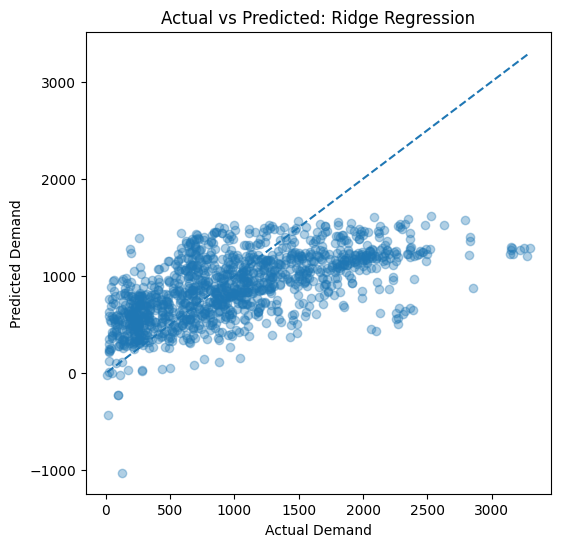

In [42]:
plot_actual_vs_predicted(
    y_true=y_val,
    y_pred=ridge_val_preds,
    model_name="Ridge Regression"
)

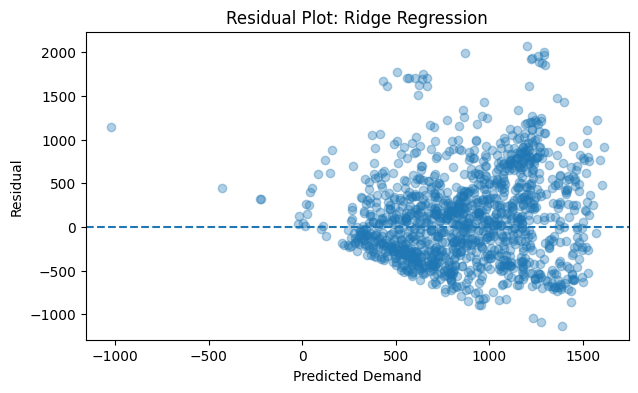

In [43]:
plot_residuals(
    y_true=y_val,
    y_pred=ridge_val_preds,
    model_name="Ridge Regression"
)

## Ridge regression note

Ridge regression achieved:

- MAE: 415.702
- RMSE: 537.330
- R²: 0.335

This is a clear improvement over the baseline, showing that the input features contain useful predictive information.

However, the actual vs predicted plot shows that ridge regression struggles with high-demand observations. This suggests that a simple linear model cannot fully capture the non-linear relationship between weather, time, and bike demand.

In [44]:
random_forest_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_val_preds = random_forest_model.predict(X_val)

rf_result = regression_metrics(
    y_true=y_val,
    y_pred=rf_val_preds,
    model_name="Random Forest Regressor"
)

Random Forest Regressor
MAE:  227.890
RMSE: 333.711
R²:   0.744


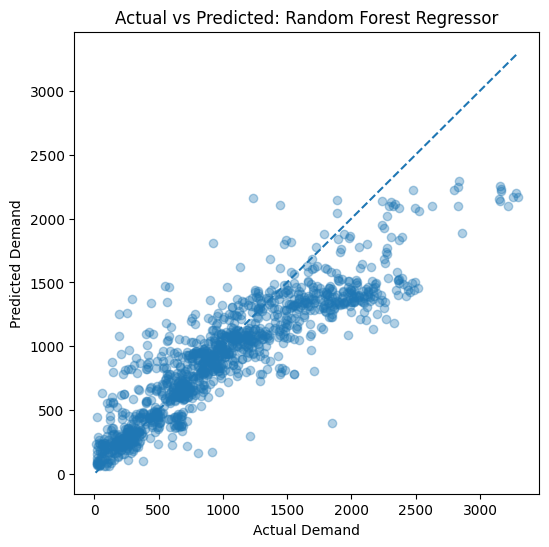

In [45]:
plot_actual_vs_predicted(
    y_true=y_val,
    y_pred=rf_val_preds,
    model_name="Random Forest Regressor"
)

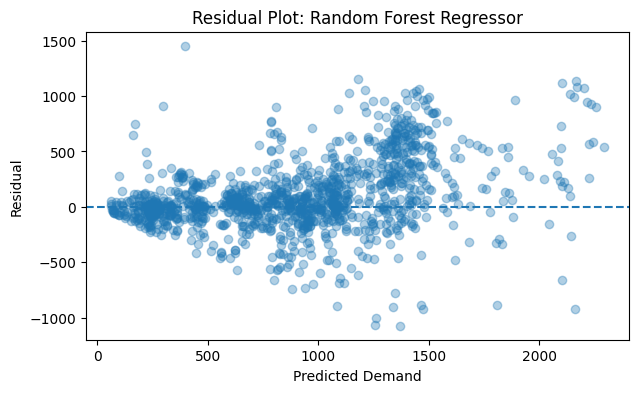

In [46]:
plot_residuals(
    y_true=y_val,
    y_pred=rf_val_preds,
    model_name="Random Forest Regressor"
)

## Random forest note

The random forest regressor achieved:

- MAE: 227.890
- RMSE: 333.711
- R²: 0.744

This is a large improvement over ridge regression and the baseline. The model captures non-linear patterns much better, especially for normal and medium demand levels.

However, the residual plot shows that the model still struggles with some high-demand periods. Some peak demand observations are underpredicted, which suggests that extreme demand is harder to capture using the current features alone.

In [47]:
gradient_boosting_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ))
])

gradient_boosting_model.fit(X_train, y_train)

gb_val_preds = gradient_boosting_model.predict(X_val)

gb_result = regression_metrics(
    y_true=y_val,
    y_pred=gb_val_preds,
    model_name="HistGradientBoosting Regressor"
)

HistGradientBoosting Regressor
MAE:  219.156
RMSE: 311.278
R²:   0.777


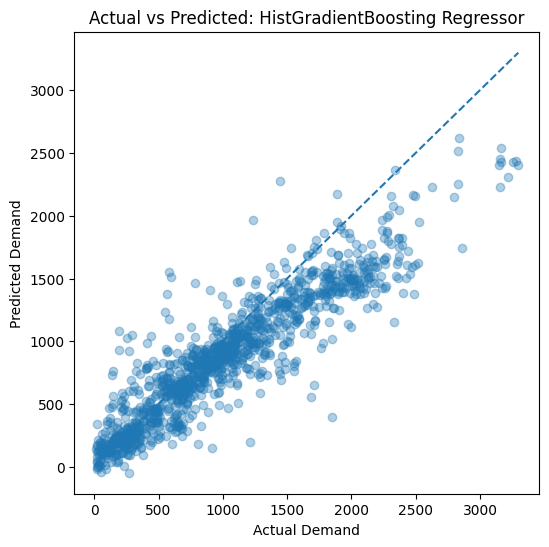

In [48]:
plot_actual_vs_predicted(
    y_true=y_val,
    y_pred=gb_val_preds,
    model_name="HistGradientBoosting Regressor"
)

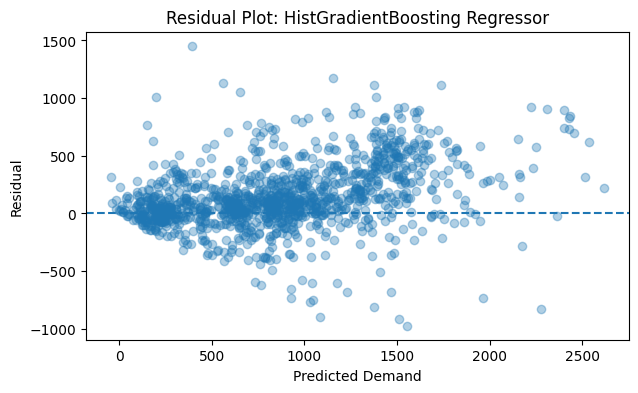

In [49]:
plot_residuals(
    y_true=y_val,
    y_pred=gb_val_preds,
    model_name="HistGradientBoosting Regressor"
)

## Gradient boosting note

The histogram gradient boosting regressor achieved:

- MAE: 219.156
- RMSE: 311.278
- R²: 0.777

This was the strongest validation model. It performed slightly better than the random forest and much better than ridge regression and the baseline.

The actual vs predicted plot shows a strong positive relationship between actual and predicted demand, although high-demand peaks are still sometimes underpredicted.

In [50]:
results_df = pd.DataFrame([
    baseline_result,
    ridge_result,
    rf_result,
    gb_result
])

results_df.sort_values("rmse")

,model,mae,rmse,r2
3,HistGradientBoosting Regressor,219.156150,311.278421,0.776924
2,Random Forest Regressor,227.889900,333.710705,0.743613
1,Ridge Regression,415.702390,537.330170,0.335281
0,Baseline Mean Regressor,565.975803,744.256279,-0.275266


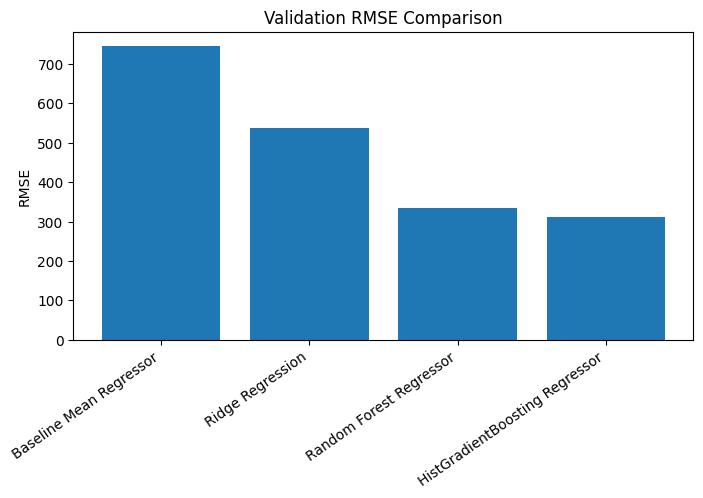

In [51]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["rmse"])
plt.title("Validation RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=35, ha="right")
plt.show()

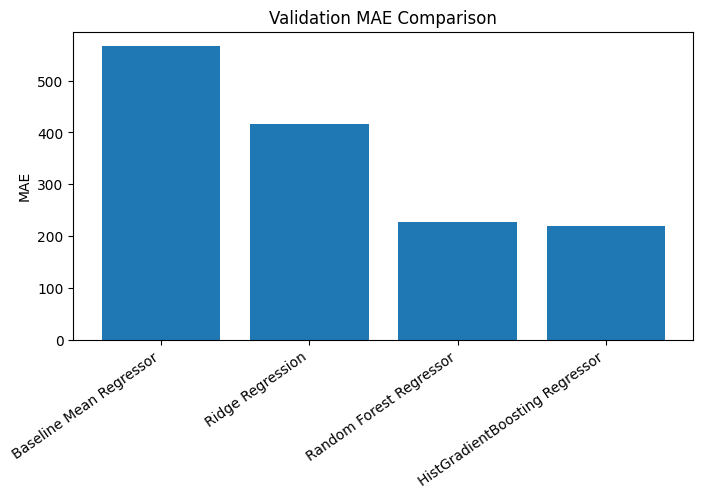

In [52]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["mae"])
plt.title("Validation MAE Comparison")
plt.ylabel("MAE")
plt.xticks(rotation=35, ha="right")
plt.show()

## Model comparison note

The best validation model was the HistGradientBoosting Regressor as shown in the plots above.

Validation results:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Baseline Mean Regressor | 565.976 | 744.256 | -0.275 |
| Ridge Regression | 415.702 | 537.330 | 0.335 |
| Random Forest Regressor | 227.890 | 333.711 | 0.744 |
| HistGradientBoosting Regressor | 219.156 | 311.278 | 0.777 |

Compared with the baseline, the best model reduced validation RMSE from 744.256 to 311.278.

This shows that weather, time, season, and holiday features provide strong predictive value for bike demand.

In [55]:
candidate_results_df = results_df[results_df["model"] != "Baseline Mean Regressor"].copy()

best_row = candidate_results_df.sort_values("rmse").iloc[0]
best_model_name = best_row["model"]

model_lookup = {
    "Ridge Regression": ridge_model,
    "Random Forest Regressor": random_forest_model,
    "HistGradientBoosting Regressor": gradient_boosting_model
}

best_model = model_lookup[best_model_name]

print("Best validation model:", best_model_name)
best_row

Best validation model: HistGradientBoosting Regressor


model    HistGradientBoosting Regressor
mae                           219.15615
rmse                         311.278421
r2                             0.776924
Name: 3, dtype: object

## Selected model note

The selected model was the HistGradientBoosting Regressor because it achieved the lowest validation RMSE among the non-baseline models.

Its validation performance was:

- MAE: 219.156
- RMSE: 311.278
- R²: 0.777

In [56]:
test_preds = best_model.predict(X_test)

# Bike demand cannot be negative, so negative predictions are clipped to zero.
test_preds = np.clip(test_preds, 0, None)

test_result = regression_metrics(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"{best_model_name}, Test Set"
)

test_result

HistGradientBoosting Regressor, Test Set
MAE:  303.840
RMSE: 381.975
R²:   0.522


{'model': 'HistGradientBoosting Regressor, Test Set',
 'mae': 303.84003475096705,
 'rmse': 381.9745647296539,
 'r2': 0.522119159959948}

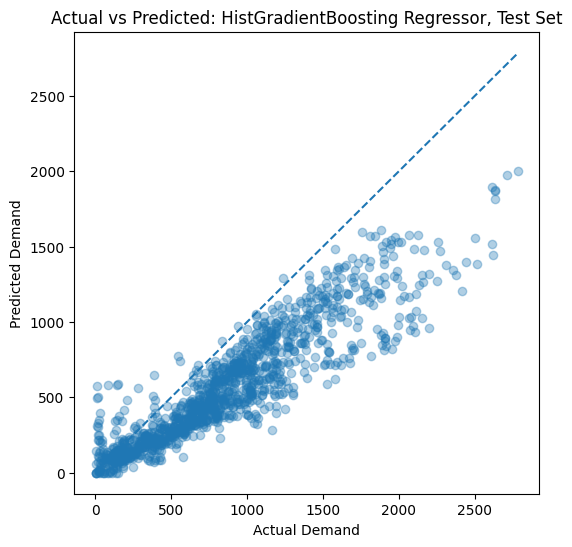

In [57]:
plot_actual_vs_predicted(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"{best_model_name}, Test Set"
)

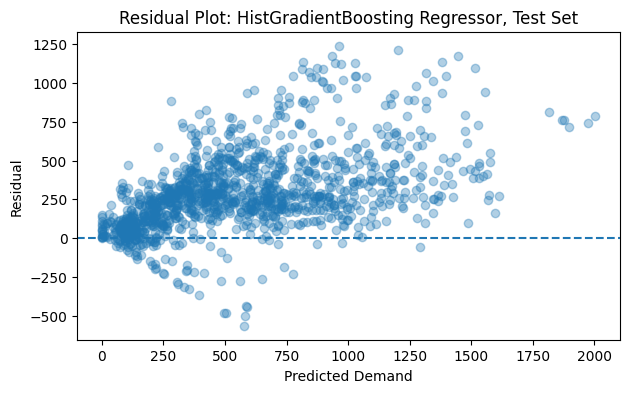

In [58]:
plot_residuals(
    y_true=y_test,
    y_pred=test_preds,
    model_name=f"{best_model_name}, Test Set"
)

## Final test result note

On the final test set, the selected HistGradientBoosting Regressor achieved:

- MAE: 303.840
- RMSE: 381.975
- R²: 0.522

The test performance is weaker than the validation performance, which suggests some distribution shift between the validation period and the final test period.

From the actual vs predicted plot, the model predicts low and medium demand reasonably well, but it often underpredicts high-demand periods. This is especially visible for observations where actual demand is above 1,500 rentals.

# Build Test Analysis Table

This table combines the test features, actual demand, predicted demand, and prediction error.

It will be used for error analysis.

In [59]:
test_analysis = X_test.copy()

test_dates = df_model.iloc[val_end:]["date"].reset_index(drop=True)

test_analysis = test_analysis.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

test_analysis["date"] = test_dates
test_analysis["actual"] = y_test_reset
test_analysis["predicted"] = test_preds
test_analysis["residual"] = test_analysis["actual"] - test_analysis["predicted"]
test_analysis["absolute_error"] = np.abs(test_analysis["residual"])

test_analysis["timestamp"] = (
    pd.to_datetime(test_analysis["date"]) 
    + pd.to_timedelta(test_analysis["hour"], unit="h")
)

test_analysis.head()

,hour,temperaturec,humiditypercent,wind_speed_m_s,visibility_10m,dew_point_temperaturec,solar_radiation_mj_m2,rainfallmm,snowfall_cm,seasons,...,hour_sin,hour_cos,month_sin,month_cos,date,actual,predicted,residual,absolute_error,timestamp
0,19,20.0,49,1.5,2000,8.9,0.0,0.0,0.0,Autumn,...,-0.965926,0.258819,-0.866025,0.5,2018-10-03,1792,1208.230714,583.769286,583.769286,2018-10-03 19:00:00
1,20,18.6,55,1.5,2000,9.3,0.0,0.0,0.0,Autumn,...,-0.866025,0.500000,-0.866025,0.5,2018-10-03,1744,1147.949906,596.050094,596.050094,2018-10-03 20:00:00
2,21,17.6,59,1.6,2000,9.4,0.0,0.0,0.0,Autumn,...,-0.707107,0.707107,-0.866025,0.5,2018-10-03,1594,1171.275284,422.724716,422.724716,2018-10-03 21:00:00
3,22,16.9,63,0.2,2000,9.8,0.0,0.0,0.0,Autumn,...,-0.500000,0.866025,-0.866025,0.5,2018-10-03,1393,1132.322573,260.677427,260.677427,2018-10-03 22:00:00
4,23,16.1,63,0.6,2000,9.0,0.0,0.0,0.0,Autumn,...,-0.258819,0.965926,-0.866025,0.5,2018-10-03,1033,769.341743,263.658257,263.658257,2018-10-03 23:00:00


In [60]:
test_analysis[
    [
        "timestamp",
        "hour",
        "seasons",
        "holiday",
        "actual",
        "predicted",
        "residual",
        "absolute_error"
    ]
].head()

,timestamp,hour,seasons,holiday,actual,predicted,residual,absolute_error
0,2018-10-03 19:00:00,19,Autumn,Holiday,1792,1208.230714,583.769286,583.769286
1,2018-10-03 20:00:00,20,Autumn,Holiday,1744,1147.949906,596.050094,596.050094
2,2018-10-03 21:00:00,21,Autumn,Holiday,1594,1171.275284,422.724716,422.724716
3,2018-10-03 22:00:00,22,Autumn,Holiday,1393,1132.322573,260.677427,260.677427
4,2018-10-03 23:00:00,23,Autumn,Holiday,1033,769.341743,263.658257,263.658257


## Test analysis table note

The test analysis table combines the original test features with actual demand, predicted demand, residuals, absolute errors, and timestamps.

This makes it easier to inspect when the model performs well or poorly.

The first few test observations already show underprediction during evening holiday hours on 2018-10-03. For example, actual demand was above 1,500 for several evening hours, while the model predicted lower values around 1,100 to 1,200.

# Error Analysis by Hour

Bike demand is strongly related to time of day.

This section checks whether the model performs better during some hours than others.

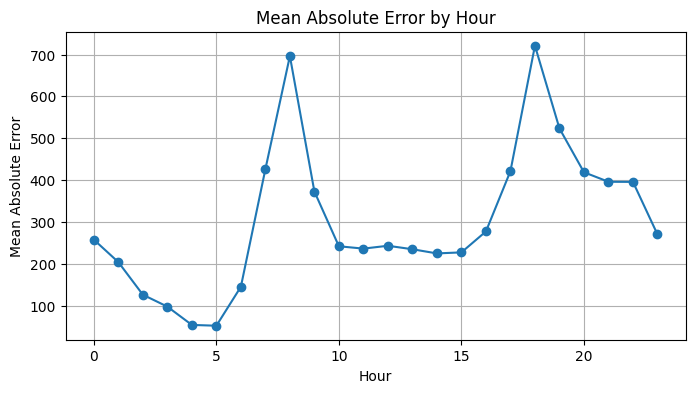

In [61]:
hour_error = test_analysis.groupby("hour")["absolute_error"].mean()

plt.figure(figsize=(8, 4))
hour_error.plot(kind="line", marker="o")
plt.title("Mean Absolute Error by Hour")
plt.xlabel("Hour")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

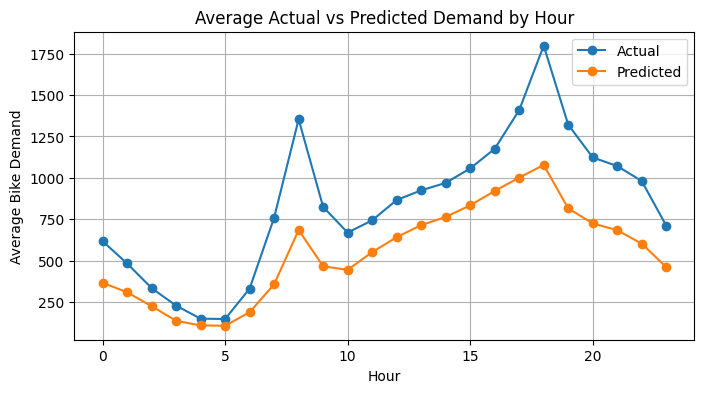

In [62]:
hour_actual_pred = test_analysis.groupby("hour")[["actual", "predicted"]].mean()

plt.figure(figsize=(8, 4))
plt.plot(hour_actual_pred.index, hour_actual_pred["actual"], marker="o", label="Actual")
plt.plot(hour_actual_pred.index, hour_actual_pred["predicted"], marker="o", label="Predicted")
plt.title("Average Actual vs Predicted Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Bike Demand")
plt.legend()
plt.grid(True)
plt.show()

## Hourly error analysis note

The model’s error changes strongly by hour.

The largest errors occur around the main commute periods, especially around 8:00 and 18:00. These are also the hours where actual demand reaches some of its highest values.

The average actual vs predicted plot shows that the model follows the general daily demand pattern, but it underpredicts the size of the morning and evening peaks.

The model performs better during low-demand early morning hours, where demand is more stable and easier to predict.

# Error Analysis by Season

Demand may change across seasons because weather and travel behaviour are different throughout the year.

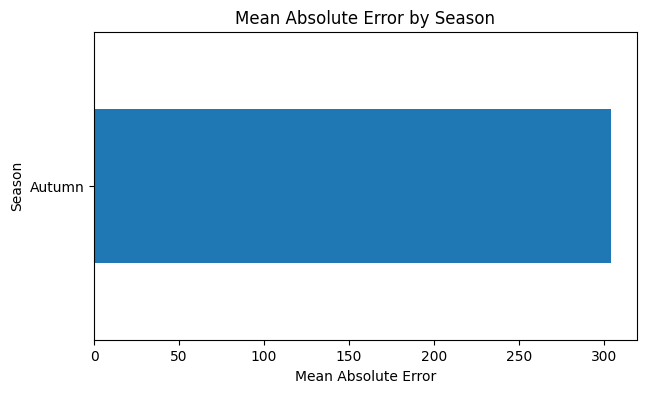

In [63]:
season_error = test_analysis.groupby("seasons")["absolute_error"].mean().sort_values()

plt.figure(figsize=(7, 4))
season_error.plot(kind="barh")
plt.title("Mean Absolute Error by Season")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Season")
plt.show()

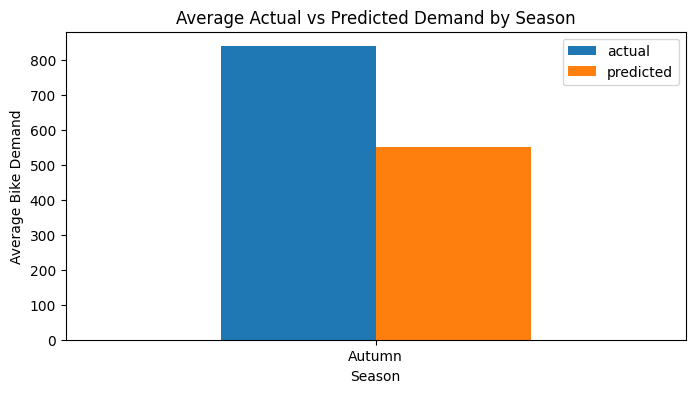

In [64]:
season_actual_pred = test_analysis.groupby("seasons")[["actual", "predicted"]].mean()

season_actual_pred.plot(kind="bar", figsize=(8, 4))
plt.title("Average Actual vs Predicted Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Bike Demand")
plt.xticks(rotation=0)
plt.show()

## Seasonal error analysis note

The final test set only contains autumn observations because of the chronological split.

Because of this, the seasonal error analysis cannot compare model performance across all seasons in the test set.

For autumn, the model underpredicts average demand. The actual average demand is clearly higher than the predicted average demand, which supports the earlier observation that the model struggles with high-demand periods in the test set.

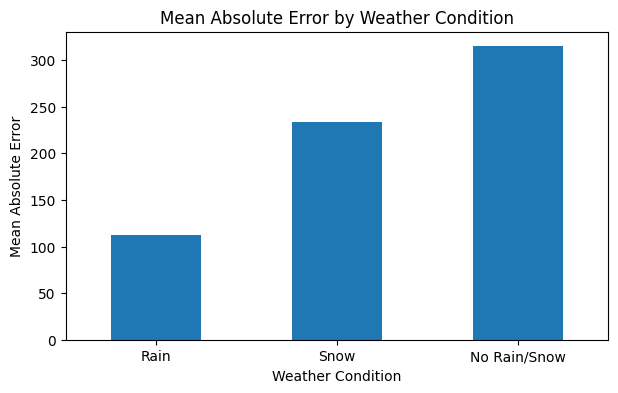

In [65]:
test_analysis["weather_condition"] = "No Rain/Snow"

test_analysis.loc[test_analysis["rainfallmm"] > 0, "weather_condition"] = "Rain"
test_analysis.loc[test_analysis["snowfall_cm"] > 0, "weather_condition"] = "Snow"

weather_error = test_analysis.groupby("weather_condition")["absolute_error"].mean().sort_values()

plt.figure(figsize=(7, 4))
weather_error.plot(kind="bar")
plt.title("Mean Absolute Error by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=0)
plt.show()

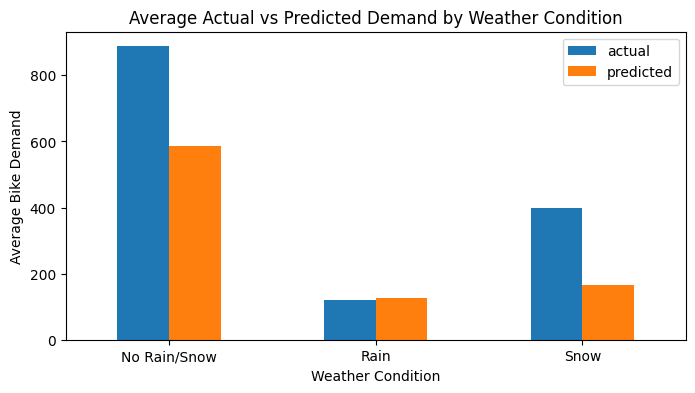

In [66]:
weather_actual_pred = test_analysis.groupby("weather_condition")[["actual", "predicted"]].mean()

weather_actual_pred.plot(kind="bar", figsize=(8, 4))
plt.title("Average Actual vs Predicted Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Bike Demand")
plt.xticks(rotation=0)
plt.show()

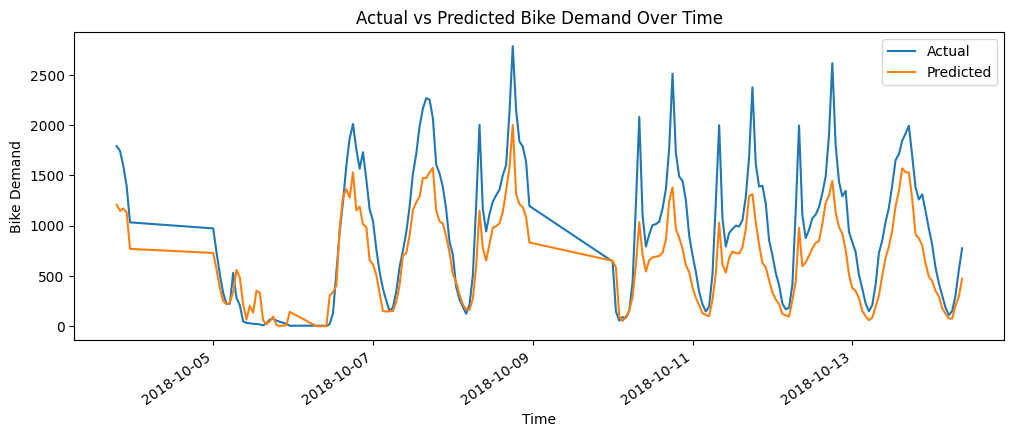

In [67]:
time_plot_df = test_analysis.sort_values("timestamp").head(200)

plt.figure(figsize=(12, 4))
plt.plot(time_plot_df["timestamp"], time_plot_df["actual"], label="Actual")
plt.plot(time_plot_df["timestamp"], time_plot_df["predicted"], label="Predicted")
plt.title("Actual vs Predicted Bike Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Bike Demand")
plt.legend()
plt.xticks(rotation=35, ha="right")
plt.show()

## Weather error analysis note

The model behaves differently across weather conditions.

The average absolute error is highest during no rain or snow conditions. This is likely because most high-demand commute periods happen during normal weather, so the largest demand peaks are also in this group.

Rainy periods have much lower average demand and lower prediction error. Snow periods show underprediction, with actual demand higher than predicted demand on average.

# Worst Prediction Cases

This section inspects the rows where the model made the largest errors.

In [68]:
worst_predictions = test_analysis.sort_values("absolute_error", ascending=False).head(15)

display_cols = [
    "timestamp",
    "hour",
    "temperaturec",
    "humiditypercent",
    "rainfallmm",
    "snowfall_cm",
    "seasons",
    "holiday",
    "actual",
    "predicted",
    "absolute_error"
]

worst_predictions[display_cols]

,timestamp,hour,temperaturec,humiditypercent,rainfallmm,snowfall_cm,seasons,holiday,actual,predicted,absolute_error
270,2018-10-17 08:00:00,8,9.2,68,0.0,0.0,Autumn,No Holiday,2202,961.928147,1240.071853
424,2018-10-23 18:00:00,18,14.5,71,0.0,0.0,Autumn,No Holiday,2415,1203.965989,1211.034011
438,2018-10-24 08:00:00,8,8.1,85,0.0,0.0,Autumn,No Holiday,2108,933.995357,1174.004643
160,2018-10-12 18:00:00,18,14.3,46,0.0,0.0,Autumn,No Holiday,2618,1446.087681,1171.912319
928,2018-11-16 18:00:00,18,9.9,74,0.0,0.0,Autumn,No Holiday,1956,818.153167,1137.846833
112,2018-10-10 18:00:00,18,12.2,45,0.0,0.0,Autumn,No Holiday,2514,1381.860652,1132.139348
294,2018-10-18 08:00:00,8,8.5,77,0.0,0.0,Autumn,No Holiday,2154,1026.791622,1127.208378
592,2018-10-30 18:00:00,18,8.4,52,0.0,0.0,Autumn,No Holiday,2074,947.673452,1126.326548
616,2018-10-31 18:00:00,18,9.4,48,0.0,0.0,Autumn,No Holiday,2094,972.961385,1121.038615
702,2018-11-05 08:00:00,8,7.2,80,0.0,0.0,Autumn,No Holiday,1975,875.441261,1099.558739


# Feature Importance with Permutation Importance

Permutation importance measures how much model performance gets worse when each feature is randomly shuffled.

If shuffling a feature increases error a lot, that feature is important for the model.

In [69]:
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_result.importances_mean,
    "std": perm_result.importances_std
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance,std
1,temperaturec,73.304878,3.181872
0,hour,65.545259,2.861452
14,hour_sin,38.965578,1.735050
2,humiditypercent,33.782256,1.820443
6,solar_radiation_mj_m2,24.543644,1.691437
13,is_weekend,16.705717,2.475660
7,rainfallmm,16.227810,1.081847
4,visibility_10m,6.259823,0.501739
15,hour_cos,3.099809,1.434568
5,dew_point_temperaturec,2.303914,0.229793


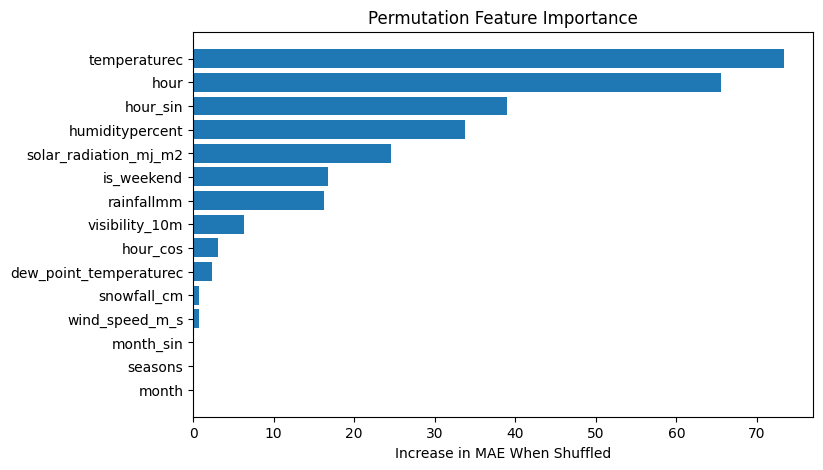

In [70]:
top_importance = importance_df.head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Permutation Feature Importance")
plt.xlabel("Increase in MAE When Shuffled")
plt.gca().invert_yaxis()
plt.show()

## Feature importance note

The most important features from permutation importance were:

1. temperaturec
2. hour
3. hour_sin
4. humiditypercent
5. solar_radiation_mj_m2

This makes sense because bike demand is strongly affected by weather and time of day.

Temperature and hour were the strongest predictors, showing that both weather comfort and daily travel patterns are important for rental demand.

Rainfall and weekend status also contributed to prediction performance, while some features such as season and month had little or no importance in the final test set. This is partly because the chronological test period only contains autumn observations, so there is limited seasonal variation in the test data.